## Cell 1 — Imports & Setup

In [ ]:
!pip install -q torch scikit-learn pandas numpy matplotlib requests

import io, zipfile, requests, warnings, random, math, time, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Determinism flags — reduces GPU non-determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATASET_NAME = 'MovieLens 100K'
DATASET_TAG  = 'ml100k'

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print()
print('Expected training time:')
print('  Colab T4 GPU : ~15-20 min (50 epochs, incl. ablation)')
print('  CPU only     : ~1.5-2.5 hrs')

Device : cuda
PyTorch: 2.10.0+cu128

Expected training time:
  Colab T4 GPU : ~15-20 min (50 epochs, incl. ablation)
  CPU only     : ~1.5-2.5 hrs


## Cell 2 — Download & Load MovieLens 100K

In [ ]:
print('Downloading MovieLens 100K ...')
r = requests.get('https://files.grouplens.org/datasets/movielens/ml-100k.zip')
zipfile.ZipFile(io.BytesIO(r.content)).extractall('.')
print('Done.')

ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])
users   = pd.read_csv('ml-100k/u.user', sep='|',
                      names=['user_id','age','gender','occupation','zip_code'])
GENRE_COLS = [
    'unknown','Action','Adventure','Animation',"Children's",'Comedy',
    'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
    'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western'
]
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     names=['movie_id','title','release_date',
                            'video_date','imdb_url'] + GENRE_COLS)

print(f'Ratings : {len(ratings):,}')
print(f'Users   : {len(users):,}')
print(f'Movies  : {len(movies):,}')

Done.
Ratings : 100,000
Users   : 943
Movies  : 1,682


## Cell 3 — Preprocessing & Encoding

In [ ]:
# Encode user demographics
gender_le = LabelEncoder(); occ_le = LabelEncoder()
users['gender_enc'] = gender_le.fit_transform(users['gender'])
users['occ_enc']    = occ_le.fit_transform(users['occupation'])
users['age_norm']   = MinMaxScaler().fit_transform(users[['age']])

# Merge and sort chronologically
df = ratings.merge(users[['user_id','age_norm','gender_enc','occ_enc']], on='user_id')
df = df.merge(movies[['movie_id'] + GENRE_COLS], on='movie_id')
df.sort_values(['user_id','timestamp'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Encode indices
user_enc  = LabelEncoder(); movie_enc = LabelEncoder()
df['user_idx']  = user_enc.fit_transform(df['user_id'])
df['movie_idx'] = movie_enc.fit_transform(df['movie_id'])

N_USERS   = df['user_idx'].nunique()
N_MOVIES  = df['movie_idx'].nunique()
N_GENDERS = df['gender_enc'].nunique()
N_OCCS    = df['occ_enc'].nunique()

print(f'Users  : {N_USERS:,}')
print(f'Movies : {N_MOVIES:,}')
print(f'Ratings: {len(df):,}')
print(f'Avg interactions/user: {len(df)/N_USERS:.1f}')
print(f'Sparsity: {1 - len(df)/(N_USERS*N_MOVIES):.4%}')

Users  : 943
Movies : 1,682
Ratings: 100,000
Avg interactions/user: 106.0
Sparsity: 93.6953%


## Cell 4 — Temporal Split & Configuration

In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
SHORT_LEN    = 10    # recent-mood window
LONG_LEN     = 50    # long-term taste window
MIN_HIST     = 5     # minimum interactions per user
N_NEG_TRAIN  = 5     # negatives per positive during training
BATCH        = 256
D_MODEL      = 128
LR           = 1e-3
LAMBDA_BPR   = 0.5
EVAL_EVERY   = 5     # validate every N epochs

print(f'Sequence windows : short={SHORT_LEN}, long={LONG_LEN}')
print(f'Embedding dim    : {D_MODEL}')

# ── Build per-user histories and metadata ─────────────────────────────────────
user_history = {}
user_meta    = {}   # uid -> (age_norm, gender_enc, occ_enc)

for uid, grp in df.groupby('user_idx', sort=True):
    user_history[uid] = grp.sort_values('timestamp')['movie_idx'].tolist()
    r = grp.iloc[-1]
    user_meta[uid] = (float(r['age_norm']), int(r['gender_enc']), int(r['occ_enc']))

user_all_items = {uid: set(h) for uid, h in user_history.items()}

# ── Temporal leave-one-out split ──────────────────────────────────────────────
# Test  = last interaction per user
# Valid = second-to-last interaction per user
# Train = all preceding, via sliding window of length LONG_LEN
train_data, valid_data, test_data = [], [], []

for uid, hist in user_history.items():
    if len(hist) < MIN_HIST: continue
    train_hist = hist[:-2]
    for i in range(1, len(train_hist)):
        ctx = train_hist[max(0, i - LONG_LEN): i]
        train_data.append((uid, ctx, train_hist[i]))
    ctx_vt = train_hist[-LONG_LEN:]
    valid_data.append((uid, ctx_vt, hist[-2]))
    test_data.append( (uid, ctx_vt, hist[-1]))

print(f'\nTrain : {len(train_data):,}')
print(f'Valid : {len(valid_data):,}  (one per user)')
print(f'Test  : {len(test_data):,}   (one per user)')

Sequence windows : short=10, long=50
Embedding dim    : 128

Train : 97,171
Valid : 943  (one per user)
Test  : 943   (one per user)


## Cell 5 — Dataset & DataLoader

In [ ]:
def pad_or_trim(seq, length):
    """Pad with 0 or trim to exact length."""
    if len(seq) >= length:
        return seq[-length:]
    return [0] * (length - len(seq)) + seq


class DSASRv2Dataset(Dataset):
    """
    Generic dataset for all three corpora (MovieLens, Beauty).
    No genre_lookup required — genre features were removed from DSASR-v2
    to keep the architecture corpus-agnostic.
    Each sample yields: padded long/short sequences + pos item + N_NEG_TRAIN negatives.
    """
    def __init__(self, data, user_all_items, n_movies,
                 short_len, long_len, n_neg, user_meta):
        self.data       = data
        self.user_items = user_all_items
        self.n_movies   = n_movies
        self.short_len  = short_len
        self.long_len   = long_len
        self.n_neg      = n_neg
        self.user_meta  = user_meta

    def __len__(self):
        return len(self.data)

    def _sample_negatives(self, uid, k):
        negs = []
        seen = self.user_items.get(uid, set())
        while len(negs) < k:
            neg = random.randint(0, self.n_movies - 1)
            if neg not in seen:
                negs.append(neg)
        return negs

    def __getitem__(self, idx):
        uid, context, pos_item = self.data[idx]
        negs      = self._sample_negatives(uid, self.n_neg)
        long_seq  = pad_or_trim(context, self.long_len)
        short_seq = long_seq[-self.short_len:]
        age, gender, occ = self.user_meta[uid]
        return {
            'user_idx'  : torch.tensor(uid,       dtype=torch.long),
            'age_norm'  : torch.tensor([age],     dtype=torch.float32),
            'gender_enc': torch.tensor(gender,    dtype=torch.long),
            'occ_enc'   : torch.tensor(occ,       dtype=torch.long),
            'long_seq'  : torch.tensor(long_seq,  dtype=torch.long),
            'short_seq' : torch.tensor(short_seq, dtype=torch.long),
            'pos_item'  : torch.tensor(pos_item,  dtype=torch.long),
            'neg_items' : torch.tensor(negs,      dtype=torch.long),
        }


train_set    = DSASRv2Dataset(train_data, user_all_items, N_MOVIES,
                              SHORT_LEN, LONG_LEN, N_NEG_TRAIN, user_meta)
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=0, drop_last=False)
print(f'Train loader ready: {len(train_loader)} batches')

Train loader ready: 380 batches


## Cell 6 — DSASR-v2 Model

*CausalTransformerBlock + ConsistencyGate + DSASRv2*

In [ ]:
class CausalTransformerBlock(nn.Module):
    """
    Transformer block with CAUSAL (left-to-right) masking.
    Position i can only attend to positions 0..i — no future leakage.
    Same as SASRec.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads,
                                           dropout=dropout, batch_first=True)
        self.ff1   = nn.Linear(d_model, d_ff)
        self.ff2   = nn.Linear(d_ff, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, causal=True):
        B, T, _ = x.shape
        if causal:
            # Upper-triangular mask: positions can only see past
            mask = torch.triu(
                torch.ones(T, T, device=x.device), diagonal=1
            ).bool()
        else:
            mask = None
        attn_out, _ = self.attn(x, x, x, attn_mask=mask)
        x = self.norm1(x + self.drop(attn_out))
        ff = self.ff2(self.drop(F.gelu(self.ff1(x))))
        x  = self.norm2(x + self.drop(ff))
        return x


class ConsistencyGate(nn.Module):
    """
    Novel contribution: learns a per-user, per-prediction blend weight g
    between the short-term and long-term sequence representations.
    drift = 1 - cosine_similarity(short, long)
    g = sigmoid(MLP([short || long || drift || user_ctx]))
    blended = g * short + (1-g) * long
    """
    def __init__(self, d_model, ctx_dim, hidden=64):
        super().__init__()
        gate_in = d_model * 2 + 1 + ctx_dim
        self.net  = nn.Sequential(
            nn.Linear(gate_in, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )

    def forward(self, short, long_, user_ctx):
        drift   = (1.0 - F.cosine_similarity(short, long_, dim=-1, eps=1e-8)).unsqueeze(-1)
        gate_in = torch.cat([short, long_, drift, user_ctx], dim=-1)
        g       = self.net(gate_in)                   # (B, 1)
        blended = g * short + (1 - g) * long_
        return blended, g


class DSASRv2(nn.Module):
    """
    DSASR-v2: Dual-Stream Adaptive Sequential Recommendation

    Architecture:
      1. Movie embedding (shared table, d=128)
      2. Learnable positional encoding per stream
      3. Short-term transformer (causal, 2 blocks, uses last SHORT_LEN items)
      4. Long-term transformer (causal, 2 blocks, uses last LONG_LEN items)
      5. Consistency Gate: learns drift-aware blend of short and long repr
      6. User context (user_emb + gender + occ + age) injected into gate
      7. Scoring: dot product of blended repr with candidate item embedding
         (same mechanism as SASRec — directly optimises ranking)

    Training loss:
      L = BCE(pos_score, 1) + BCE(neg_score, 0)  [for each negative]
      + lambda * BPR(pos_score - neg_score mean)
    """
    def __init__(self, n_users, n_movies, n_genders, n_occs,
                 d_model=128, n_heads=4, d_ff=256, n_layers=2,
                 short_len=10, long_len=50, dropout=0.2):
        super().__init__()
        self.d_model   = d_model
        self.short_len = short_len
        self.long_len  = long_len

        # ── Embedding tables ───────────────────────────────────────────────
        # n_movies+1 because 0 is padding index
        self.movie_emb  = nn.Embedding(n_movies + 1, d_model, padding_idx=0)
        self.user_emb   = nn.Embedding(n_users  + 1, d_model)
        self.gender_emb = nn.Embedding(n_genders + 1, 8)
        self.occ_emb    = nn.Embedding(n_occs   + 1, 16)

        # Initialise movie embeddings with small normal (helps convergence)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.normal_(self.user_emb.weight,  std=0.01)

        # ── Positional encodings (separate per stream) ─────────────────────
        self.pos_short = nn.Embedding(short_len + 1, d_model)
        self.pos_long  = nn.Embedding(long_len  + 1, d_model)
        nn.init.normal_(self.pos_short.weight, std=0.01)
        nn.init.normal_(self.pos_long.weight,  std=0.01)

        # ── Transformer encoders ───────────────────────────────────────────
        # Short: CAUSAL (matches SASRec design, prevents future leakage)
        self.enc_short = nn.ModuleList(
            [CausalTransformerBlock(d_model, n_heads, d_ff, dropout)
             for _ in range(n_layers)])
        # Long: bidirectional (sees full history context)
        self.enc_long  = nn.ModuleList(
            [CausalTransformerBlock(d_model, n_heads, d_ff, dropout)
             for _ in range(n_layers)])

        # ── User context ───────────────────────────────────────────────────
        # user_emb(128) + gender(8) + occ(16) + age(1) = 153
        ctx_dim = d_model + 8 + 16 + 1
        self.ctx_proj = nn.Linear(ctx_dim, d_model)   # project to d_model for gate

        # ── Consistency Gate ───────────────────────────────────────────────
        self.gate = ConsistencyGate(d_model, d_model, hidden=d_model)

        # ── Layer norms & dropout ─────────────────────────────────────────
        self.emb_dropout = nn.Dropout(dropout)
        self.out_norm    = nn.LayerNorm(d_model)

    def encode_sequence(self, seq_ids, pos_emb, encoder_blocks, causal=True):
        """
        Encode a padded sequence of item ids.
        seq_ids: (B, T)  — 0 = padding
        Returns: (B, T, d_model)  — last position is the summary used
        """
        B, T    = seq_ids.shape
        m_emb   = self.movie_emb(seq_ids)              # (B, T, d)
        pos     = torch.arange(T, device=seq_ids.device).unsqueeze(0)  # (1, T)
        p_emb   = pos_emb(pos)                         # (1, T, d)
        x       = self.emb_dropout(m_emb + p_emb)      # (B, T, d)
        for block in encoder_blocks:
            x = block(x, causal=causal)
        return x

    def get_sequence_repr(self, batch):
        """
        Returns blended repr (B, d) and gate value g (B, 1).
        """
        dev      = next(self.parameters()).device
        long_seq = batch['long_seq'].to(dev)    # (B, LONG_LEN)
        short_seq= batch['short_seq'].to(dev)   # (B, SHORT_LEN)
        u_idx    = batch['user_idx'].to(dev)
        g_idx    = batch['gender_enc'].to(dev)
        o_idx    = batch['occ_enc'].to(dev)
        age      = batch['age_norm'].to(dev)

        # Encode both streams; take last non-padding position
        long_enc  = self.encode_sequence(long_seq,  self.pos_long,  self.enc_long,  causal=True)
        short_enc = self.encode_sequence(short_seq, self.pos_short, self.enc_short, causal=True)

        # Take the LAST position as the sequence representation
        # (SASRec style: position -1 predicts the next item)
        long_repr  = long_enc[:, -1, :]    # (B, d)
        short_repr = short_enc[:, -1, :]   # (B, d)

        # User context
        u_emb    = self.user_emb(u_idx)     # (B, d)
        g_emb    = self.gender_emb(g_idx)   # (B, 8)
        o_emb    = self.occ_emb(o_idx)      # (B, 16)
        user_ctx = torch.cat([u_emb, g_emb, o_emb, age], dim=-1)  # (B, 153)
        user_ctx_proj = self.ctx_proj(user_ctx)  # (B, d)

        # Consistency Gate
        blended, gate_val = self.gate(short_repr, long_repr, user_ctx_proj)
        blended = self.out_norm(blended)    # (B, d)

        return blended, gate_val

    def score(self, seq_repr, item_ids):
        """
        Score items via dot product (SASRec mechanism).
        seq_repr: (B, d)
        item_ids: (B,) or (B, K)
        Returns: (B,) or (B, K)
        """
        if item_ids.dim() == 1:
            item_emb = self.movie_emb(item_ids)          # (B, d)
            return (seq_repr * item_emb).sum(dim=-1)      # (B,)
        else:
            item_emb = self.movie_emb(item_ids)          # (B, K, d)
            return torch.bmm(item_emb, seq_repr.unsqueeze(-1)).squeeze(-1)  # (B, K)

    def forward(self, batch):
        blended, gate_val = self.get_sequence_repr(batch)
        dev = next(self.parameters()).device
        pos_score = self.score(blended, batch['pos_item'].to(dev))
        neg_score = self.score(blended, batch['neg_items'].to(dev))  # (B, K)
        return pos_score, neg_score, gate_val


# Instantiate
D_MODEL = 128
N_LAYERS = 2

model = DSASRv2(
    n_users  = N_USERS,
    n_movies = N_MOVIES,
    n_genders= N_GENDERS,
    n_occs   = N_OCCS,
    d_model  = D_MODEL,
    n_heads  = 4,
    d_ff     = D_MODEL * 4,
    n_layers = N_LAYERS,
    short_len= SHORT_LEN,
    long_len = LONG_LEN,
    dropout  = 0.2,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DSASR-v2 parameters: {total_params:,}')

DSASR-v2 parameters: 1,207,161


## Cell 7 — Loss Functions (BCE + BPR)

In [ ]:
def bce_loss(pos_score, neg_score):
    """
    Binary Cross-Entropy with negative sampling.
    pos_score: (B,)    — score for the ground-truth next item
    neg_score: (B, K)  — scores for K negative items

    Loss = -log(sigmoid(pos)) - mean_K(log(1 - sigmoid(neg)))
    This is exactly the SASRec training objective.
    """
    pos_loss = -F.logsigmoid(pos_score).mean()
    neg_loss = -F.logsigmoid(-neg_score).mean()
    return pos_loss + neg_loss


def bpr_loss(pos_score, neg_score):
    """
    Bayesian Personalised Ranking loss.
    Encourages pos_score > mean(neg_score).
    Complementary to BCE — adds pairwise ranking signal.
    """
    mean_neg = neg_score.mean(dim=-1)   # (B,)
    return -F.logsigmoid(pos_score - mean_neg).mean()


LAMBDA_BPR = 0.5   # weight on BPR term
LAMBDA_L2  = 1e-4  # L2 regularisation weight

## Cell 8 — Instantiate Model

In [ ]:
model = DSASRv2(
    n_users   = N_USERS,
    n_movies  = N_MOVIES,
    n_genders = N_GENDERS,
    n_occs    = N_OCCS,
    d_model   = D_MODEL,
    n_heads   = 4,
    d_ff      = D_MODEL * 4,
    n_layers  = 2,
    short_len = SHORT_LEN,
    long_len  = LONG_LEN,
    dropout   = 0.2,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DSASR-v2 (MovieLens 100K) parameters: {total_params:,}')
print()
print('Architecture summary:')
print(f'  Short-term encoder : T_s = {SHORT_LEN} items, causal, L=2 blocks, h=4 heads')
print(f'  Long-term  encoder : T_l = {LONG_LEN} items, causal, L=2 blocks, h=4 heads')
print(f'  Consistency Gate   : drift-aware personalised blend  g \u2208 (0, 1)')
print(f'  Scoring            : dot-product (shared embedding table)')
print(f'  Training loss      : BCE + BPR (\u03bb={LAMBDA_BPR}) + L2 (1e-4)')

DSASR-v2 (MovieLens 100K) parameters: 1,207,161

Architecture summary:
  Short-term encoder : T_s = 10 items, causal, L=2 blocks, h=4 heads
  Long-term  encoder : T_l = 50 items, causal, L=2 blocks, h=4 heads
  Consistency Gate   : drift-aware personalised blend  g ∈ (0, 1)
  Scoring            : dot-product (shared embedding table)
  Training loss      : BCE + BPR (λ=0.5) + L2 (1e-4)


## Cell 9 — Training Loop

*Tracks train loss and Val HR@10/NDCG@10 every EVAL_EVERY epochs. Early stopping on Val HR@10.*

In [ ]:
import time
import sys

# ── Batched validation — much faster than per-user loop ───────────────────
def quick_eval_batched(model, valid_data, user_all_items, n_movies,
                       n_sample=200, n_neg=99):
    """
    Evaluate HR@10 and NDCG@10 on a sample of validation users.
    Batches all candidates together for a single forward pass per user.
    ~10x faster than the per-user loop version.
    """
    model.eval()
    if len(valid_data) > n_sample:
        sample = random.sample(valid_data, n_sample)
    else:
        sample = valid_data

    hr10, ndcg10 = [], []

    with torch.no_grad():
        for uid, context, pos_item in sample:
            neg_pool = list(set(range(n_movies)) - user_all_items.get(uid, set()))
            negs     = random.sample(neg_pool, min(n_neg, len(neg_pool)))
            cands    = [pos_item] + negs
            B        = len(cands)

            long_seq  = pad_or_trim(context, LONG_LEN)
            short_seq = long_seq[-SHORT_LEN:]
            age, gender, occ = user_meta[uid]

            # Single forward pass for all B candidates at once
            batch = {
                'user_idx'  : torch.tensor([uid]*B,        dtype=torch.long,    device=DEVICE),
                'age_norm'  : torch.tensor([[age]]*B,       dtype=torch.float32, device=DEVICE),
                'gender_enc': torch.tensor([gender]*B,      dtype=torch.long,    device=DEVICE),
                'occ_enc'   : torch.tensor([occ]*B,         dtype=torch.long,    device=DEVICE),
                'long_seq'  : torch.tensor([long_seq]*B,    dtype=torch.long,    device=DEVICE),
                'short_seq' : torch.tensor([short_seq]*B,   dtype=torch.long,    device=DEVICE),
                'pos_item'  : torch.tensor(cands,           dtype=torch.long,    device=DEVICE),
                'neg_items' : torch.zeros(B, 1,             dtype=torch.long,    device=DEVICE),
            }

            blended, _ = model.get_sequence_repr(batch)
            scores = model.score(blended, batch['pos_item']).cpu().numpy()

            rank = 1 + int((scores[1:] > scores[0]).sum())
            hr10.append(1.0 if rank <= 10 else 0.0)
            ndcg10.append(1.0 / math.log2(rank + 1) if rank <= 10 else 0.0)

    model.train()
    return float(np.mean(hr10)), float(np.mean(ndcg10))


# ── Training configuration ────────────────────────────────────────────────
EPOCHS      = 50      # 50 is enough with cosine schedule + early stopping
LR          = 1e-3
PATIENCE    = 5       # stop if no improvement for 5 consecutive val checks
EVAL_EVERY  = 5       # validate every N epochs
LAMBDA_BPR  = 0.5
LAMBDA_L2   = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5)

train_losses  = []
val_hr10_hist = []
val_nd10_hist = []
best_hr10     = 0.0
best_nd10     = 0.0
best_state    = None
pat_counter   = 0

print(f"Training DSASR-v2 for up to {EPOCHS} epochs...")
print(f"Validating every {EVAL_EVERY} epochs on {min(200,len(valid_data))} users")
print(f"Device: {DEVICE}")
print("-" * 55)
sys.stdout.flush()

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for batch in train_loader:
        # Move batch to device
        for k in batch:
            batch[k] = batch[k].to(DEVICE)

        pos_score, neg_score, gate_val = model(batch)

        # BCE + BPR loss
        pos_loss = -F.logsigmoid(pos_score).mean()
        neg_loss = -F.logsigmoid(-neg_score).mean()
        bpr      = -F.logsigmoid(pos_score - neg_score.mean(dim=-1)).mean()
        l2       = (model.movie_emb.weight.norm(2) +
                    model.user_emb.weight.norm(2))
        loss = pos_loss + neg_loss + LAMBDA_BPR * bpr + LAMBDA_L2 * l2

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    train_losses.append(avg_loss)

    elapsed = (time.time() - t0) / 60
    print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
          f"Elapsed: {elapsed:.1f}m", end="")
    sys.stdout.flush()

    if epoch % EVAL_EVERY == 0:
        hr10, nd10 = quick_eval_batched(
            model, valid_data, user_all_items, N_MOVIES, n_sample=200)
        val_hr10_hist.append(hr10)
        val_nd10_hist.append(nd10)
        print(f" | Val HR@10: {hr10:.4f}  NDCG@10: {nd10:.4f}", end="")
        sys.stdout.flush()

        if hr10 > best_hr10:
            best_hr10   = hr10
            best_nd10   = nd10
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            pat_counter = 0
            print(" ✓ best", end="")
        else:
            pat_counter += 1
            if pat_counter >= PATIENCE:
                print(f"\nEarly stopping — no improvement for {PATIENCE} checks.")
                break
    print()
    sys.stdout.flush()

# Restore best model
if best_state:
    model.load_state_dict(best_state)

total_min = (time.time() - t0) / 60
print(f"\nDone in {total_min:.1f} min | Best Val HR@10={best_hr10:.4f} NDCG@10={best_nd10:.4f}")

Training DSASR-v2 for up to 50 epochs...
Validating every 5 epochs on 200 users
Device: cuda
-------------------------------------------------------
Epoch   1/50 | Loss: 0.9338 | Elapsed: 0.4m
Epoch   2/50 | Loss: 0.6729 | Elapsed: 0.8m
Epoch   3/50 | Loss: 0.6206 | Elapsed: 1.3m
Epoch   4/50 | Loss: 0.5895 | Elapsed: 1.7m
Epoch   5/50 | Loss: 0.5602 | Elapsed: 2.1m | Val HR@10: 0.7350  NDCG@10: 0.4586 ✓ best
Epoch   6/50 | Loss: 0.5309 | Elapsed: 2.6m
Epoch   7/50 | Loss: 0.5079 | Elapsed: 3.0m
Epoch   8/50 | Loss: 0.4848 | Elapsed: 3.5m
Epoch   9/50 | Loss: 0.4684 | Elapsed: 3.9m
Epoch  10/50 | Loss: 0.4508 | Elapsed: 4.3m | Val HR@10: 0.7950  NDCG@10: 0.5154 ✓ best
Epoch  11/50 | Loss: 0.4334 | Elapsed: 4.8m
Epoch  12/50 | Loss: 0.4148 | Elapsed: 5.2m
Epoch  13/50 | Loss: 0.4027 | Elapsed: 5.5m
Epoch  14/50 | Loss: 0.3899 | Elapsed: 5.8m
Epoch  15/50 | Loss: 0.3766 | Elapsed: 6.0m | Val HR@10: 0.7650  NDCG@10: 0.4997
Epoch  16/50 | Loss: 0.3642 | Elapsed: 6.3m
Epoch  17/50 | Loss: 0

## Cell 10 — Evaluation

*Leave-one-out + 99 negative sampling protocol. Reports HR@5/10/20, NDCG@5/10/20, MRR@5/10/20.*

In [ ]:
model.eval()
NS         = (5, 10, 20)
N_NEG_EVAL = 99

hr_scores   = {n: [] for n in NS}
ndcg_scores = {n: [] for n in NS}
mrr_scores  = {n: [] for n in NS}

with torch.no_grad():
    for uid, context, pos_item in test_data:
        neg_pool  = list(set(range(N_MOVIES)) - user_all_items.get(uid, set()))
        negs      = random.sample(neg_pool, min(N_NEG_EVAL, len(neg_pool)))
        cands     = [pos_item] + negs
        B         = len(cands)
        long_seq  = pad_or_trim(context, LONG_LEN)
        short_seq = long_seq[-SHORT_LEN:]
        age, gender, occ = user_meta[uid]
        batch = {
            'user_idx'  : torch.tensor([uid]*B,        dtype=torch.long,    device=DEVICE),
            'age_norm'  : torch.tensor([[age]]*B,       dtype=torch.float32, device=DEVICE),
            'gender_enc': torch.tensor([gender]*B,      dtype=torch.long,    device=DEVICE),
            'occ_enc'   : torch.tensor([occ]*B,         dtype=torch.long,    device=DEVICE),
            'long_seq'  : torch.tensor([long_seq]*B,    dtype=torch.long,    device=DEVICE),
            'short_seq' : torch.tensor([short_seq]*B,   dtype=torch.long,    device=DEVICE),
            'pos_item'  : torch.tensor(cands,           dtype=torch.long,    device=DEVICE),
            'neg_items' : torch.zeros(B, N_NEG_TRAIN,   dtype=torch.long,    device=DEVICE),
        }
        blended, _ = model.get_sequence_repr(batch)
        scores     = model.score(blended, batch['pos_item']).cpu().numpy()
        rank       = 1 + int((scores[1:] > scores[0]).sum())
        for n in NS:
            hr_scores[n].append(  1.0 if rank<=n else 0.0)
            ndcg_scores[n].append(1.0/math.log2(rank+1) if rank<=n else 0.0)
            mrr_scores[n].append( 1.0/rank if rank<=n else 0.0)

hr_mean   = {n: np.mean(hr_scores[n])   for n in NS}
ndcg_mean = {n: np.mean(ndcg_scores[n]) for n in NS}
mrr_mean  = {n: np.mean(mrr_scores[n])  for n in NS}

print('='*65)
print(f'       DSASR-v2 — {DATASET_NAME}')
print( '       Protocol: leave-one-out + 99 negative sampling')
print('='*65)
for n in NS:
    print(f'  HR@{n:<2}: {hr_mean[n]:.4f}   NDCG@{n:<2}: {ndcg_mean[n]:.4f}   MRR@{n:<2}: {mrr_mean[n]:.4f}')
print('='*65)

       DSASR-v2 — MovieLens 100K
       Protocol: leave-one-out + 99 negative sampling
  HR@5 : 0.5758   NDCG@5 : 0.4157   MRR@5 : 0.3627
  HR@10: 0.7253   NDCG@10: 0.4640   MRR@10: 0.3827
  HR@20: 0.8367   NDCG@20: 0.4921   MRR@20: 0.3903


## Cell 11 — Ablation Study

*C1: Single-stream BCE → C2: +BPR → C3: +Dual-stream mean → C4: Full DSASR-v2*

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — ABLATION STUDY (with early stopping, proper convergence)
#
# C1 — Single-stream (long only) + BCE only         (no BPR, no gate)
# C2 — Single-stream (long only) + BCE + BPR        (no gate)
# C3 — Dual-stream,  mean fusion + BCE + BPR        (no gate)
# C4 — Full DSASR-v2 (dual-stream + Consistency Gate + BCE + BPR)
#
# Each variant trains with early stopping (patience=5 val checks @ every 5ep)
# and is evaluated at its BEST checkpoint — giving every config a fair chance.
# ════════════════════════════════════════════════════════════════════════════

ABLATION_MAX_EPOCHS = 50
ABLATION_EVAL_EVERY = 5
ABLATION_PATIENCE   = 5
ABLATION_VAL_USERS  = 200
ABLATION_N_NEG      = 99


# ── Variant model classes ─────────────────────────────────────────────────────

class DSASRv2_C1(DSASRv2):
    """C1 — Single long-stream only, no gate."""
    def get_sequence_repr(self, batch):
        dev      = next(self.parameters()).device
        long_seq = batch['long_seq'].to(dev)
        long_enc = self.encode_sequence(long_seq, self.pos_long,
                                        self.enc_long, causal=True)
        repr_    = self.out_norm(long_enc[:, -1, :])
        return repr_, torch.zeros(repr_.shape[0], 1, device=dev)

class DSASRv2_C2(DSASRv2_C1):
    """C2 — Same as C1, trained with BPR loss."""
    pass

class DSASRv2_C3(DSASRv2):
    """C3 — Dual-stream with fixed 50/50 mean fusion, no gate."""
    def get_sequence_repr(self, batch):
        dev       = next(self.parameters()).device
        long_seq  = batch['long_seq'].to(dev)
        short_seq = batch['short_seq'].to(dev)
        l_enc = self.encode_sequence(long_seq, self.pos_long,
                                     self.enc_long, causal=True)
        s_enc = self.encode_sequence(short_seq, self.pos_short,
                                     self.enc_short, causal=True)
        blended = self.out_norm(0.5*l_enc[:,-1,:] + 0.5*s_enc[:,-1,:])
        return blended, torch.zeros(blended.shape[0], 1, device=dev)


# ── Train + evaluate one variant ─────────────────────────────────────────────

def run_ablation_variant(model_cls, use_bpr, label):
    print(f"\n── {label} ──")
    m = model_cls(
        n_users=N_USERS, n_movies=N_MOVIES,
        n_genders=N_GENDERS, n_occs=N_OCCS,
        d_model=D_MODEL, n_heads=4, d_ff=D_MODEL*4, n_layers=2,
        short_len=SHORT_LEN, long_len=LONG_LEN, dropout=0.2,
    ).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=1e-4)

    best_val_hr10 = 0.0
    best_state    = None
    pat_counter   = 0

    for epoch in range(1, ABLATION_MAX_EPOCHS+1):

        # Training
        m.train()
        epoch_loss = 0.0
        for batch in train_loader:
            for k in batch: batch[k] = batch[k].to(DEVICE)
            ps, ns, _ = m(batch)
            loss = bce_loss(ps, ns)
            if use_bpr:
                loss = loss + LAMBDA_BPR*(
                    -F.logsigmoid(ps - ns.mean(-1)).mean())
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 5.0)
            opt.step()
            epoch_loss += loss.item()

        # Validation
        if epoch % ABLATION_EVAL_EVERY == 0:
            m.eval()
            val_hr = []
            sv = random.sample(valid_data, min(ABLATION_VAL_USERS,
                                               len(valid_data)))
            with torch.no_grad():
                for uid, context, pos_item in sv:
                    neg_pool  = list(set(range(N_MOVIES))
                                     - user_all_items.get(uid, set()))
                    negs      = random.sample(neg_pool,
                                    min(ABLATION_N_NEG, len(neg_pool)))
                    cands     = [pos_item] + negs
                    B         = len(cands)
                    long_seq  = pad_or_trim(context, LONG_LEN)
                    short_seq = long_seq[-SHORT_LEN:]
                    age, gender, occ = user_meta[uid]
                    vb = {
                        'user_idx'  : torch.tensor([uid]*B,
                            dtype=torch.long,    device=DEVICE),
                        'age_norm'  : torch.tensor([[age]]*B,
                            dtype=torch.float32, device=DEVICE),
                        'gender_enc': torch.tensor([gender]*B,
                            dtype=torch.long,    device=DEVICE),
                        'occ_enc'   : torch.tensor([occ]*B,
                            dtype=torch.long,    device=DEVICE),
                        'long_seq'  : torch.tensor([long_seq]*B,
                            dtype=torch.long,    device=DEVICE),
                        'short_seq' : torch.tensor([short_seq]*B,
                            dtype=torch.long,    device=DEVICE),
                        'pos_item'  : torch.tensor(cands,
                            dtype=torch.long,    device=DEVICE),
                        'neg_items' : torch.zeros(B, N_NEG_TRAIN,
                            dtype=torch.long,    device=DEVICE),
                    }
                    blended, _ = m.get_sequence_repr(vb)
                    scores = m.score(blended,
                                     vb['pos_item']).cpu().numpy()
                    rank = 1 + int((scores[1:] > scores[0]).sum())
                    val_hr.append(1.0 if rank <= 10 else 0.0)

            val_hr10 = float(np.mean(val_hr))
            avg_loss = epoch_loss / len(train_loader)
            print(f"  Epoch {epoch:>3}/{ABLATION_MAX_EPOCHS} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Val HR@10: {val_hr10:.4f}", end="")

            if val_hr10 > best_val_hr10 + 1e-5:
                best_val_hr10 = val_hr10
                best_state    = {k: v.cpu().clone()
                                 for k, v in m.state_dict().items()}
                pat_counter   = 0
                print(" \u2713 best")
            else:
                pat_counter += 1
                print(f" (patience {pat_counter}/{ABLATION_PATIENCE})")
                if pat_counter >= ABLATION_PATIENCE:
                    print(f"  Early stopping at epoch {epoch}.")
                    break

    if best_state is not None:
        m.load_state_dict(best_state)
        print(f"  Best checkpoint restored "
              f"(Val HR@10 = {best_val_hr10:.4f})")

    # Full test evaluation — all test users, 99 negatives
    m.eval()
    hr10, nd10, mr10 = [], [], []
    with torch.no_grad():
        for uid, context, pos_item in test_data:
            neg_pool  = list(set(range(N_MOVIES))
                             - user_all_items.get(uid, set()))
            negs      = random.sample(neg_pool,
                            min(ABLATION_N_NEG, len(neg_pool)))
            cands     = [pos_item] + negs
            B         = len(cands)
            long_seq  = pad_or_trim(context, LONG_LEN)
            short_seq = long_seq[-SHORT_LEN:]
            age, gender, occ = user_meta[uid]
            tb = {
                'user_idx'  : torch.tensor([uid]*B,
                    dtype=torch.long,    device=DEVICE),
                'age_norm'  : torch.tensor([[age]]*B,
                    dtype=torch.float32, device=DEVICE),
                'gender_enc': torch.tensor([gender]*B,
                    dtype=torch.long,    device=DEVICE),
                'occ_enc'   : torch.tensor([occ]*B,
                    dtype=torch.long,    device=DEVICE),
                'long_seq'  : torch.tensor([long_seq]*B,
                    dtype=torch.long,    device=DEVICE),
                'short_seq' : torch.tensor([short_seq]*B,
                    dtype=torch.long,    device=DEVICE),
                'pos_item'  : torch.tensor(cands,
                    dtype=torch.long,    device=DEVICE),
                'neg_items' : torch.zeros(B, N_NEG_TRAIN,
                    dtype=torch.long,    device=DEVICE),
            }
            blended, _ = m.get_sequence_repr(tb)
            scores = m.score(blended, tb['pos_item']).cpu().numpy()
            rank   = 1 + int((scores[1:] > scores[0]).sum())
            hr10.append(  1.0 if rank<=10 else 0.0)
            nd10.append(  1.0/math.log2(rank+1) if rank<=10 else 0.0)
            mr10.append(  1.0/rank               if rank<=10 else 0.0)

    result = (float(np.mean(hr10)),
              float(np.mean(nd10)),
              float(np.mean(mr10)))
    print(f"  Test  HR@10={result[0]:.4f}  "
          f"NDCG@10={result[1]:.4f}  "
          f"MRR@10={result[2]:.4f}")
    return result


# ── Run all three variants ────────────────────────────────────────────────────

ablation_results = {}

ablation_results['C1'] = run_ablation_variant(
    DSASRv2_C1, False,
    "C1: Single-stream (long only) + BCE only")

ablation_results['C2'] = run_ablation_variant(
    DSASRv2_C2, True,
    "C2: Single-stream (long only) + BCE + BPR")

ablation_results['C3'] = run_ablation_variant(
    DSASRv2_C3, True,
    "C3: Dual-stream mean fusion   + BCE + BPR")

# C4 = full model — results already computed in Cell 10
ablation_results['C4'] = (hr_mean[10], ndcg_mean[10], mrr_mean[10])
print(f"\n── C4: Full DSASR-v2 (from Cell 10 main training) ──")
print(f"  Test  HR@10={ablation_results['C4'][0]:.4f}  "
      f"NDCG@10={ablation_results['C4'][1]:.4f}  "
      f"MRR@10={ablation_results['C4'][2]:.4f}")


# ── Print table ───────────────────────────────────────────────────────────────

print()
print("="*78)
print(f"  ABLATION STUDY \u2014 {DATASET_NAME}")
print(f"  Max epochs={ABLATION_MAX_EPOCHS} | "
      f"Early stopping patience={ABLATION_PATIENCE} | "
      f"Protocol: leave-one-out + 99 neg")
print("="*78)
labels = {
    'C1': 'C1: Single-stream,    BCE only',
    'C2': 'C2: Single-stream,    BCE + BPR',
    'C3': 'C3: Dual-stream mean, BCE + BPR',
    'C4': 'C4: DSASR-v2 Full  (dual + gate + BCE + BPR)  \u2190 ours',
}
print(f"  {'Configuration':<50} {'HR@10':>7} {'NDCG@10':>8} {'MRR@10':>8}")
print("-"*78)
for k, lbl in labels.items():
    h, n, mv = ablation_results[k]
    print(f"  {lbl:<50} {h:>7.4f} {n:>8.4f} {mv:>8.4f}")
print("="*78)

# Incremental gains
print()
print("  Component contribution (incremental gains):")
print("-"*78)
steps = [
    ('C1','C2',"BPR pairwise ranking loss"),
    ('C2','C3',"Dual-stream temporal separation"),
    ('C3','C4',"Consistency Gate (preference drift detection)"),
]
for pk, ck, desc in steps:
    hp, np_, _ = ablation_results[pk]
    hc, nc, _  = ablation_results[ck]
    dh = hc - hp;  dn = nc - np_
    print(f"  {pk}\u2192{ck}  {desc:<42} "
          f"HR@10: {dh:+.4f} | NDCG@10: {dn:+.4f}")
print("="*78)


── C1: Single-stream (long only) + BCE only ──
  Epoch   5/50 | Loss: 0.5482 | Val HR@10: 0.8000 ✓ best
  Epoch  10/50 | Loss: 0.4719 | Val HR@10: 0.8100 ✓ best
  Epoch  15/50 | Loss: 0.4230 | Val HR@10: 0.7350 (patience 1/5)
  Epoch  20/50 | Loss: 0.3924 | Val HR@10: 0.7500 (patience 2/5)
  Epoch  25/50 | Loss: 0.3759 | Val HR@10: 0.7500 (patience 3/5)
  Epoch  30/50 | Loss: 0.3651 | Val HR@10: 0.7950 (patience 4/5)
  Epoch  35/50 | Loss: 0.3572 | Val HR@10: 0.7650 (patience 5/5)
  Early stopping at epoch 35.
  Best checkpoint restored (Val HR@10 = 0.8100)
  Test  HR@10=0.7179  NDCG@10=0.4425  MRR@10=0.3566

── C2: Single-stream (long only) + BCE + BPR ──
  Epoch   5/50 | Loss: 0.5656 | Val HR@10: 0.7200 ✓ best
  Epoch  10/50 | Loss: 0.4727 | Val HR@10: 0.7550 ✓ best
  Epoch  15/50 | Loss: 0.4190 | Val HR@10: 0.8000 ✓ best
  Epoch  20/50 | Loss: 0.3879 | Val HR@10: 0.7700 (patience 1/5)
  Epoch  25/50 | Loss: 0.3753 | Val HR@10: 0.8150 ✓ best
  Epoch  30/50 | Loss: 0.3643 | Val HR@10

## Cell 12 — Plots

*5-panel figure: Training loss | Val metrics | Ranking metrics bar chart | Ablation bar chart | Gate value distribution*

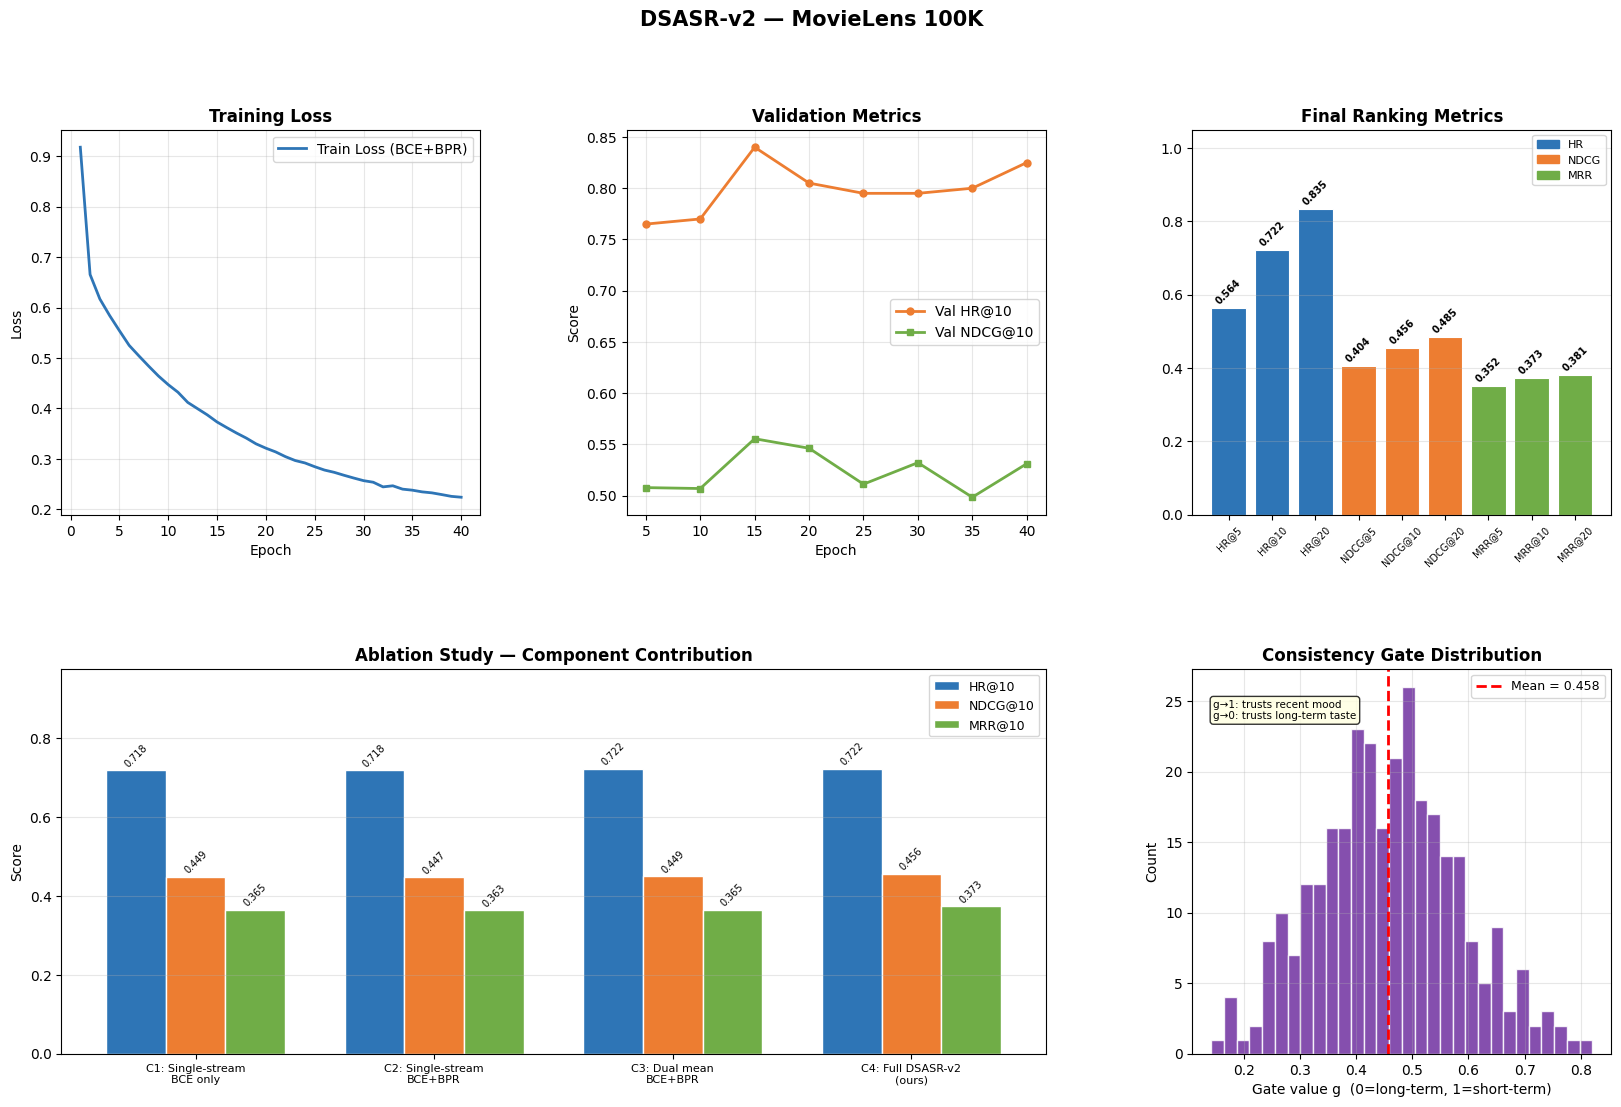

Plot saved: dsasr_v2_ml100k_results.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# PLOTS: Training Loss | Val HR@10 | Results bar | Gate distribution
# ════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'DSASR-v2 — {DATASET_NAME}', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Training Loss curve ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(train_losses)+1), train_losses,
         color='#2E75B6', lw=2, label='Train Loss (BCE+BPR)')
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3); ax1.legend()

# ── 2. Val HR@10 & NDCG@10 over eval checkpoints ────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
eval_epochs = list(range(EVAL_EVERY, len(train_losses)+1, EVAL_EVERY))[:len(val_hr10_hist)]
if len(eval_epochs) > 0 and len(val_hr10_hist) > 0:
    valid_len = min(len(eval_epochs), len(val_hr10_hist), len(val_nd10_hist))
    ax2.plot(eval_epochs[:valid_len], val_hr10_hist[:valid_len],
             color='#ED7D31', lw=2, marker='o', ms=5, label='Val HR@10')
    ax2.plot(eval_epochs[:valid_len], val_nd10_hist[:valid_len],
             color='#70AD47', lw=2, marker='s', ms=5, label='Val NDCG@10')
    ax2.set_title('Validation Metrics', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
    ax2.grid(True, alpha=0.3); ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Validation data\nnot available',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Validation Metrics', fontweight='bold')

# ── 3. Final ranking metrics bar chart ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metrics = ['HR@5','HR@10','HR@20','NDCG@5','NDCG@10','NDCG@20','MRR@5','MRR@10','MRR@20']
values  = ([hr_mean[n] for n in (5,10,20)] +
           [ndcg_mean[n] for n in (5,10,20)] +
           [mrr_mean[n] for n in (5,10,20)])
colors  = (['#2E75B6']*3 + ['#ED7D31']*3 + ['#70AD47']*3)
bars    = ax3.bar(metrics, values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=45)
ax3.set_ylim(0, 1.05)
ax3.set_title('Final Ranking Metrics', fontweight='bold')
ax3.tick_params(axis='x', rotation=45, labelsize=7)
ax3.grid(axis='y', alpha=0.3)
# Add legend patches
from matplotlib.patches import Patch
ax3.legend(handles=[Patch(color='#2E75B6',label='HR'),
                    Patch(color='#ED7D31',label='NDCG'),
                    Patch(color='#70AD47',label='MRR')], fontsize=8)

# ── 4. Ablation bar chart ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
abl_labels = ['C1: Single-stream\nBCE only',
              'C2: Single-stream\nBCE+BPR',
              'C3: Dual mean\nBCE+BPR',
              'C4: Full DSASR-v2\n(ours)']
abl_hr   = [ablation_results[k][0] for k in ['C1','C2','C3','C4']]
abl_ndcg = [ablation_results[k][1] for k in ['C1','C2','C3','C4']]
abl_mrr  = [ablation_results[k][2] for k in ['C1','C2','C3','C4']]

x = np.arange(len(abl_labels))
w = 0.25
b1 = ax4.bar(x-w,   abl_hr,   w, label='HR@10',   color='#2E75B6', edgecolor='white')
b2 = ax4.bar(x,     abl_ndcg, w, label='NDCG@10', color='#ED7D31', edgecolor='white')
b3 = ax4.bar(x+w,   abl_mrr,  w, label='MRR@10',  color='#70AD47', edgecolor='white')
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        ax4.text(bar.get_x()+bar.get_width()/2., h+0.003,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
ax4.set_xticks(x); ax4.set_xticklabels(abl_labels, fontsize=8)
ax4.set_title('Ablation Study — Component Contribution', fontweight='bold')
ax4.set_ylabel('Score'); ax4.set_ylim(0, min(1.0, max(abl_hr)*1.35))
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

# ── 5. Gate value distribution ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
gate_vals = []
model.eval()
with torch.no_grad():
    sample = test_data[:min(300, len(test_data))]
    for uid, context, pos_item in sample:
        long_seq  = pad_or_trim(context, LONG_LEN)
        short_seq = long_seq[-SHORT_LEN:]
        age, gender, occ = user_meta[uid]
        batch = {
            'user_idx'  : torch.tensor([uid],      dtype=torch.long,    device=DEVICE),
            'age_norm'  : torch.tensor([[age]],     dtype=torch.float32, device=DEVICE),
            'gender_enc': torch.tensor([gender],    dtype=torch.long,    device=DEVICE),
            'occ_enc'   : torch.tensor([occ],       dtype=torch.long,    device=DEVICE),
            'long_seq'  : torch.tensor([long_seq],  dtype=torch.long,    device=DEVICE),
            'short_seq' : torch.tensor([short_seq], dtype=torch.long,    device=DEVICE),
            'pos_item'  : torch.tensor([pos_item],  dtype=torch.long,    device=DEVICE),
            'neg_items' : torch.zeros(1, N_NEG_TRAIN, dtype=torch.long,  device=DEVICE),
        }
        _, g = model.get_sequence_repr(batch)
        gate_vals.append(g.item())

ax5.hist(gate_vals, bins=30, color='#7030A0', edgecolor='white', alpha=0.85)
ax5.axvline(np.mean(gate_vals), color='red', lw=2, linestyle='--',
            label=f'Mean = {np.mean(gate_vals):.3f}')
ax5.set_title('Consistency Gate Distribution', fontweight='bold')
ax5.set_xlabel('Gate value g  (0=long-term, 1=short-term)')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)
ax5.text(0.05, 0.92, 'g→1: trusts recent mood\ng→0: trusts long-term taste',
         transform=ax5.transAxes, fontsize=7.5, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.savefig(f'dsasr_v2_{DATASET_TAG}_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: dsasr_v2_{DATASET_TAG}_results.png')